# Project 3 — Multimodal BEV Perception

**Experiment ID:** P3-1  
**Architecture:** Data Preprocessing & Multimodal Dataset Construction      
**Task:** BEV Occupancy Prediction  
**Dataset:** nuScenes-mini

This notebook converts raw NuScenes sensor data into synchronized
multimodal training samples used throughout Project 3.

The preprocessing pipeline:

- loads synchronized camera, LiDAR and ego-motion data
- preprocesses RGB imagery
- converts LiDAR point clouds into Bird's-Eye-View (BEV) occupancy maps
- extracts IMU-style motion features
- stores synchronized triplets as HDF5 files

The generated dataset is used by all subsequent RGB, LiDAR and Fusion models.

## Metadata

**Project**

Cross-Domain Multimodal Sensor Fusion for BEV Occupancy Prediction

**Dataset**

NuScenes Mini v1.0

**Input Modalities**

- RGB Camera
- LiDAR Point Cloud
- Ego Motion (IMU)

**Output**

HDF5 multimodal samples

```
sample_xxxxx.h5
├── rgb
├── bev
└── imu
```

## Pipeline Overview

```text
NuScenes

Camera Image
      │
      ▼
RGB Preprocessing
      │
      ▼
Normalized RGB

LiDAR Point Cloud
      │
      ▼
BEV Projection
      │
      ▼
Occupancy Map

Ego Pose
      │
      ▼
IMU Features

      │
      ▼
HDF5 Dataset
```

## 1. Environment Setup

Mount Google Drive and configure the project workspace.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')
%cd /content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception
!ls

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception
assets	     colab_packages  deployment  nuscenes  results
checkpoints  data	     notebooks	 reports   src


## 2. Imports

Import standard libraries, NuScenes utilities and project-specific preprocessing modules.

In [ ]:
import os, sys
# --- System ---
sys.path.append('/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/colab_packages')


In [ ]:

import sys, os, importlib
# Make sure your src/ directory is visible to Python
project_root = "/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception"
src_path = os.path.join(project_root, "src")

if src_path not in sys.path:
    sys.path.append(src_path)
    print(f" Added to sys.path: {src_path}")

# Clear any stale caches
importlib.invalidate_caches()

 Added to sys.path: /content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/src


In [ ]:
# --- External Libraries ---
import numpy as np
import h5py, cv2, open3d as o3d, matplotlib.pyplot as plt
from tqdm import tqdm
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud

# --- From src utilities ---
# Project-specific preprocessing utilities
# preprocess_rgb()  : RGB normalization
# lidar_to_bev()    : Point cloud → occupancy grid
from preprocess_utils import preprocess_rgb, lidar_to_bev

## 3. Initialize NuScenes

Create the NuScenes interface used to access synchronized
camera, LiDAR and ego-motion data.

In [ ]:

# --- Paths ---
DATA_ROOT =  "/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/nuscenes"
VERSION = "v1.0-mini"
!pwd
OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/data/preprocessed"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Initialize NuScenes ---
nusc = NuScenes(version=VERSION, dataroot=DATA_ROOT, verbose=True)
print(f" Loaded {len(nusc.sample)} samples.")


/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 1.007 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.
 Loaded 404 samples.


## 4. Helper Function

The helper below stores one synchronized multimodal sample.

Each HDF5 file contains

- RGB tensor
- BEV occupancy map
- IMU feature vector

This format allows efficient loading during model training.

In [ ]:
def save_triplet(path, rgb, bev, imu):
    """
    Save one synchronized multimodal training sample.

    Parameters
    ----------
    path : str
        Output HDF5 filename.

    rgb : ndarray
        Preprocessed RGB image.

    bev : ndarray
        LiDAR-derived BEV occupancy map.

    imu : ndarray
        Ego-motion feature vector.
    """
    with h5py.File(path, "w") as f:
        f.create_dataset("rgb", data=rgb, compression="gzip")
        f.create_dataset("bev", data=bev, compression="gzip")
        f.create_dataset("imu", data=imu, compression="gzip")


## 5. Construct Multimodal Dataset

For every NuScenes sample:

1. Load RGB image
2. Load LiDAR point cloud
3. Generate BEV occupancy grid
4. Extract ego-motion features
5. Save synchronized HDF5 sample

### Implementation

The helper functions below construct one synchronized multimodal sample
from a NuScenes scene.

Each sample consists of:

- **RGB:** Preprocessed front-camera image
- **BEV:** LiDAR-derived Bird's-Eye-View (BEV) occupancy grid
- **IMU:** Ego-motion feature window computed from neighboring vehicle poses

These three modalities are synchronized and stored as a single HDF5
training sample, which serves as the input to all subsequent RGB,
LiDAR, and multimodal fusion models.

In [ ]:
# ============================================================
# Configuration & Multimodal Sample Extraction
# ============================================================
#
# This section defines:
#
# 1. Global preprocessing parameters
# 2. Quaternion utilities
# 3. Ego-motion (IMU) feature extraction
# 4. Construction of synchronized RGB–BEV–IMU samples
#
# ============================================================

# ---------------------------------------------------
# Global preprocessing configuration
# ---------------------------------------------------

IMG_SIZE = (256, 256)

# Spatial extent (meters)
X_RANGE = (-50, 50)
Y_RANGE = (-50, 50)

# BEV grid resolution (meters / pixel)
RES = 0.5

import math
from pyquaternion import Quaternion

def quaternion_to_euler(q):
    """
    Convert a quaternion orientation into Euler angles.

    Parameters
    ----------
    q : array-like
        Quaternion in (w, x, y, z) format.

    Returns
    -------
    ndarray
        Roll, pitch and yaw angles (radians).
    """
    qw, qx, qy, qz = q
    yaw = np.arctan2(2*(qw*qz + qx*qy), 1 - 2*(qy**2 + qz**2))
    pitch = np.arcsin(np.clip(2*(qw*qy - qz*qx), -1.0, 1.0))
    roll = np.arctan2(2*(qw*qx + qy*qz), 1 - 2*(qx**2 + qy**2))
    return np.array([roll, pitch, yaw], np.float32)

def extract_imu_window(nusc, sample_token, window=10):
    """
    Extract a temporal ego-motion feature window.

    The vehicle's linear and angular velocities are computed
    from consecutive ego poses within the same NuScenes scene.

    The resulting IMU-style feature sequence captures the
    vehicle's recent motion history and is later used as the
    third modality in the fusion network.

    Returns
    -------
    imu_window : ndarray
        Shape (window, 6)

        [vx, vy, vz,
         wx, wy, wz]
    """
    # ---------------------------------------------------
    # Locate current sample within the scene
    # ---------------------------------------------------
    sample = nusc.get('sample', sample_token)
    scene = nusc.get('scene', sample['scene_token'])

    # ---------------------------------------------------
    # Traverse the complete sample sequence
    # ---------------------------------------------------
    s_token = scene['first_sample_token']
    samples = []
    while s_token:
        s = nusc.get('sample', s_token)
        samples.append(s)
        s_token = s['next']

    # Find current sample index
    idx = [i for i,s in enumerate(samples) if s['token']==sample_token][0]

    # Compute motion deltas for ±window/2 neighbors
    imu_feats = []
    # ---------------------------------------------------
    # Compute linear and angular velocities
    # ---------------------------------------------------
    for j in range(max(0, idx - window//2), min(len(samples)-1, idx + window//2)):
        s1, s2 = samples[j], samples[j+1]
        sd1 = nusc.get('sample_data', s1['data']['LIDAR_TOP'])
        sd2 = nusc.get('sample_data', s2['data']['LIDAR_TOP'])
        p1 = nusc.get('ego_pose', sd1['ego_pose_token'])
        p2 = nusc.get('ego_pose', sd2['ego_pose_token'])
        t1, t2 = p1['timestamp']/1e6, p2['timestamp']/1e6
        dt = max(t2 - t1, 1e-3)
        v = (np.array(p2['translation']) - np.array(p1['translation'])) / dt
        q1, q2 = Quaternion(p1['rotation']), Quaternion(p2['rotation'])
        e1, e2 = quaternion_to_euler(q1.elements), quaternion_to_euler(q2.elements)
        w = (e2 - e1) / dt
        imu_feats.append(np.concatenate([v, w]))

    if len(imu_feats)==0:
        imu_feats = [np.zeros(6, np.float32)]
    imu_window = np.stack(imu_feats[-window:], axis=0)
    # ---------------------------------------------------
    # Pad short sequences to fixed window length
    # ---------------------------------------------------
    if imu_window.shape[0] < window:
        pad = np.zeros((window - imu_window.shape[0], 6), np.float32)
        imu_window = np.vstack([pad, imu_window])
    return imu_window.astype(np.float32)

def extract_triplet(nusc, sample):
    """
    Construct one synchronized multimodal training sample.

    Each sample contains three aligned modalities:

    1. RGB image
    2. LiDAR-derived BEV occupancy map
    3. Ego-motion (IMU) feature window

    These synchronized modalities form the input to all
    subsequent perception and fusion models.
    """
    try:
        # ---------------------------------------------------
        # Load synchronized sensor records
        # ---------------------------------------------------
        cam_token = sample['data']['CAM_FRONT']
        lidar_token = sample['data']['LIDAR_TOP']

        # ---------------------------------------------------
        # Load and preprocess RGB image
        # ---------------------------------------------------
        img_path = nusc.get_sample_data_path(cam_token)
        rgb = preprocess_rgb(img_path, size=(256, 256))

        # ---------------------------------------------------
        # Convert LiDAR point cloud to BEV occupancy grid
        # ---------------------------------------------------
        lidar_path, _, _ = nusc.get_sample_data(lidar_token)
        lidar_data = LidarPointCloud.from_file(lidar_path)
        bev = lidar_to_bev(lidar_data.points.T[:, :3])
        bev = np.expand_dims(bev, 0)

        # ---------------------------------------------------
        # Extract ego-motion feature window
        # ---------------------------------------------------)
        imu_window = extract_imu_window(nusc, sample['token'], window=10)
        # ---------------------------------------------------
        # Return synchronized multimodal sample
        # ---------------------------------------------------
        return rgb, bev, imu_window
    except Exception as e:
        print(f"[WARN] Failed to construct sample: {e}")
        return None, None, None


## 7. Moving Scene Verification

Before filtering the dataset, inspect the ego-motion trajectories to
confirm that vehicle motion has been extracted correctly.

This diagnostic visualizes the vehicle trajectory within a selected
NuScenes scene and provides a qualitative verification of the
computed ego-motion features.

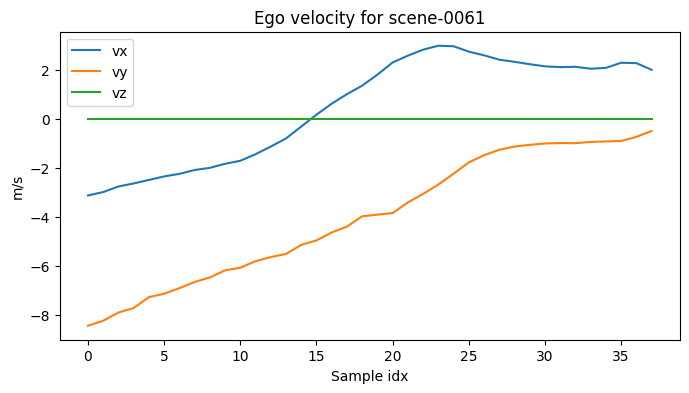

In [ ]:
def plot_scene_motion(nusc, scene_name):
    """
    Visualize ego-vehicle motion for a NuScenes scene.

    This diagnostic computes the ego vehicle's linear velocity by
    differentiating consecutive ego poses obtained from the LiDAR
    timestamps. The resulting velocity profiles (vx, vy, vz) provide
    a qualitative verification that the selected scene contains
    meaningful vehicle motion.

    Parameters
    ----------
    nusc : NuScenes
        Initialized NuScenes dataset object.

    scene_name : str
        Name of the scene to visualize (e.g., "scene-0061").

    Notes
    -----
    - Velocities are estimated using finite differences between
      consecutive ego poses.
    - The plot is intended for preprocessing diagnostics only and
      is not used during model training.
    """

    # ---------------------------------------------------
    # Locate the requested scene
    # ---------------------------------------------------
    scene = [s for s in nusc.scene if s['name']==scene_name][0]
    token = scene['first_sample_token']
    poses, times = [], []

    # ---------------------------------------------------
    # Traverse all samples in the scene
    # ---------------------------------------------------
    while token:
        sample = nusc.get('sample', token)
        sd = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
        pose = nusc.get('ego_pose', sd['ego_pose_token'])
        poses.append(np.array(pose['translation']))
        times.append(pose['timestamp']/1e6)
        token = sample['next']

    # ---------------------------------------------------
    # Estimate linear velocity from consecutive poses
    # ---------------------------------------------------
    poses, times = np.stack(poses), np.array(times)
    v = np.diff(poses, axis=0)/np.diff(times)[:,None]

    # ---------------------------------------------------
    # Visualize ego-vehicle velocity
    # ---------------------------------------------------
    plt.figure(figsize=(8,4))
    plt.plot(v[:,0], label='vx')
    plt.plot(v[:,1], label='vy')
    plt.plot(v[:,2], label='vz')
    plt.legend(); plt.title(f"Ego velocity for {scene_name}")
    plt.xlabel("Sample idx"); plt.ylabel("m/s"); plt.show()

# Example: this scene usually moves
plot_scene_motion(nusc, "scene-0061")


## 8. Scene Motion Statistics

Quantitatively measure ego-vehicle motion across every NuScenes scene.

For each scene, the mean and maximum ego-vehicle speeds are computed
from consecutive ego poses. These statistics are used to identify
dynamic driving sequences and construct a moving-scene subset for
subsequent model training.

Scene        | Mean Speed (m/s) | Max Speed (m/s) | Status
-----------------------------------------------------------------
scene-0061   | 4.770           | 8.988           |  Moving
scene-0103   | 6.071           | 8.993           |  Moving
scene-0553   | 0.000           | 0.000           |  Stationary
scene-0655   | 8.235           | 8.918           |  Moving
scene-0757   | 1.403           | 5.126           |  Moving
scene-0796   | 12.085          | 12.971          |  Moving
scene-0916   | 4.692           | 6.128           |  Moving
scene-1077   | 12.633          | 15.165          |  Moving
scene-1094   | 6.473           | 12.722          |  Moving
scene-1100   | 0.055           | 0.643           |  Stationary


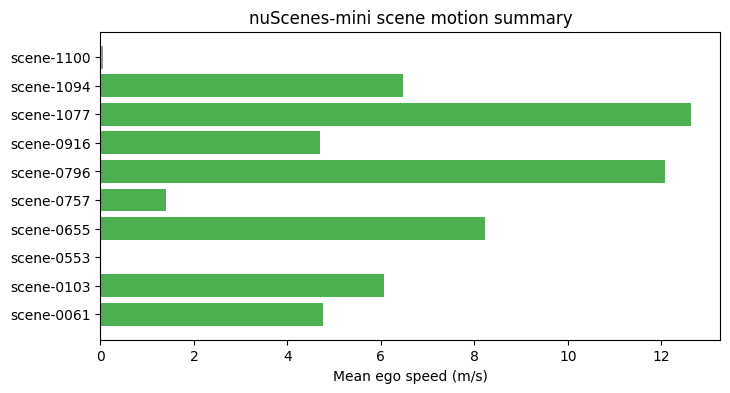

In [ ]:
def get_scene_speed_stats(nusc, scene_name):
    """
    Compute ego-vehicle motion statistics for a NuScenes scene.

    This diagnostic traverses every sample within a scene, estimates the
    ego vehicle's linear velocity from consecutive ego poses, and
    summarizes the overall scene motion.

    The statistics are used to distinguish dynamic driving scenes from
    stationary scenes during dataset construction.

    Parameters
    ----------
    nusc : NuScenes
        Initialized NuScenes dataset object.

    scene_name : str
        Name of the scene to analyze.

    Returns
    -------
    mean_speed : float
        Mean ego-vehicle speed (m/s).

    max_speed : float
        Maximum ego-vehicle speed (m/s).
    """

    # ---------------------------------------------------
    # Locate the requested scene
    # ---------------------------------------------------
    scene = [s for s in nusc.scene if s['name'] == scene_name][0]
    token = scene['first_sample_token']
    poses, times = [], []

    # ---------------------------------------------------
    # Traverse all samples within the scene
    # ---------------------------------------------------
    while token:
        sample = nusc.get('sample', token)
        sd = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
        pose = nusc.get('ego_pose', sd['ego_pose_token'])
        poses.append(np.array(pose['translation']))
        times.append(pose['timestamp'] / 1e6)
        token = sample['next']

    # ---------------------------------------------------
    # Estimate ego-vehicle velocity
    # ---------------------------------------------------
    poses, times = np.stack(poses), np.array(times)
    v = np.diff(poses, axis=0) / np.diff(times)[:, None]

    # ---------------------------------------------------
    # Compute scene motion statistics
    # ---------------------------------------------------
    speeds = np.linalg.norm(v, axis=1)
    return np.mean(speeds), np.max(speeds)

# Scan all scenes
motion_summary = []
for scene in nusc.scene:
    mean_speed, max_speed = get_scene_speed_stats(nusc, scene['name'])
    motion_summary.append((scene['name'], mean_speed, max_speed))

# Print summary
print(f"{'Scene':<12} | {'Mean Speed (m/s)':<15} | {'Max Speed (m/s)':<15} | Status")
print("-" * 65)
for name, mean_s, max_s in motion_summary:
    status = " Moving" if mean_s > 0.5 else " Stationary"
    print(f"{name:<12} | {mean_s:<15.3f} | {max_s:<15.3f} | {status}")

# Optional: visualize sorted by mean speed
import matplotlib.pyplot as plt
scenes = [x[0] for x in motion_summary]
mean_speeds = [x[1] for x in motion_summary]
plt.figure(figsize=(8,4))
plt.barh(scenes, mean_speeds, color=['#4CAF50' if s>0.5 else '#999999' for s in mean_speeds])
plt.xlabel("Mean ego speed (m/s)")
plt.title("nuScenes-mini scene motion summary")
plt.show()


## 9. Generate the Preprocessed Dataset

Iterate through every NuScenes sample and generate synchronized
multimodal HDF5 files.

For each sample:

1. Extract synchronized RGB, LiDAR and ego-motion data
2. Construct the multimodal triplet
3. Save the sample as an HDF5 file

This dataset serves as the input to all subsequent learning stages.

In [ ]:
print(f"Generating preprocessed samples → {OUTPUT_DIR}")

for i, sample in enumerate(tqdm(nusc.sample)):

    # Extract synchronized multimodal sample
    rgb, bev, imu = extract_triplet(nusc, sample)

    # Skip samples that could not be processed
    if rgb is None:
        continue

    # Save one HDF5 training sample
    out_path = os.path.join(OUTPUT_DIR, f"sample_{i:05d}.h5")
    save_triplet(out_path, rgb, bev, imu)

print(" All samples saved successfully!")


Generating preprocessed samples → /content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/data/preprocessed


100%|██████████| 404/404 [00:34<00:00, 11.85it/s]

 All samples saved successfully!


## 10. Dataset Verification

Inspect randomly selected HDF5 samples to verify:

- RGB image quality
- BEV occupancy map generation
- IMU feature extraction

This step provides a qualitative sanity check before model training.

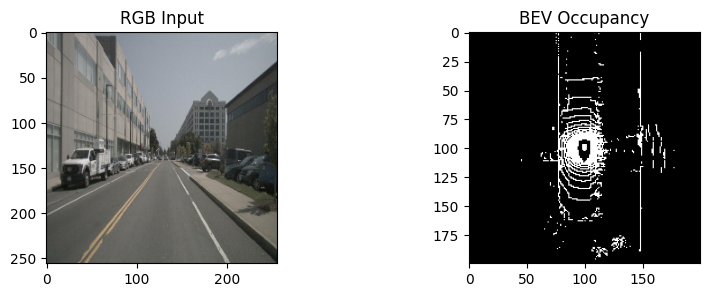

In [ ]:
# Load one processed sample and visualize
import random
files = [f for f in os.listdir(OUTPUT_DIR) if f.endswith(".h5")]
rand_file = os.path.join(OUTPUT_DIR, random.choice(files))

with h5py.File(rand_file, "r") as f:
    rgb = np.array(f["rgb"])
    bev = np.array(f["bev"])

plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.imshow(np.transpose(rgb, (1,2,0))*0.5+0.5)
plt.title("RGB Input")

plt.subplot(1,2,2)
plt.imshow(bev[0], cmap="gray")
plt.title("BEV Occupancy")
plt.show()


## 11. Moving Scene Extraction

Many autonomous-driving scenes contain stationary vehicles
or negligible motion.

To better emphasize dynamic driving behaviour, a secondary
dataset containing only moving scenes is constructed.

The resulting dataset is used in the subsequent learning phases.

In [ ]:
from nuscenes.nuscenes import NuScenes
from src.extract_moving_scenes import extract_moving_scenes

DATA_ROOT =  "/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/nuscenes"
VERSION   = "v1.0-mini"

nusc = NuScenes(version=VERSION, dataroot=DATA_ROOT, verbose=False)
extract_moving_scenes(nusc)


 Scanning scenes for motion ...
 Found 8 moving scenes: ['scene-0061', 'scene-0103', 'scene-0655', 'scene-0757', 'scene-0796', 'scene-0916', 'scene-1077', 'scene-1094']

 Copying moving samples ...


100%|██████████| 8/8 [01:06<00:00,  8.37s/it]

 Copied 323 moving samples → data/preprocessed_moving


## 12. Moving Dataset Verification

Verify the generated moving-scene dataset through visual inspection.

This final verification confirms that:

- moving samples were extracted correctly
- RGB and BEV remain synchronized
- preprocessing completed successfully

Sample: /content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/data/preprocessed_moving/sample_00073.h5
RGB shape: (3, 256, 256), BEV shape: (1, 200, 200), IMU shape: (10, 6)


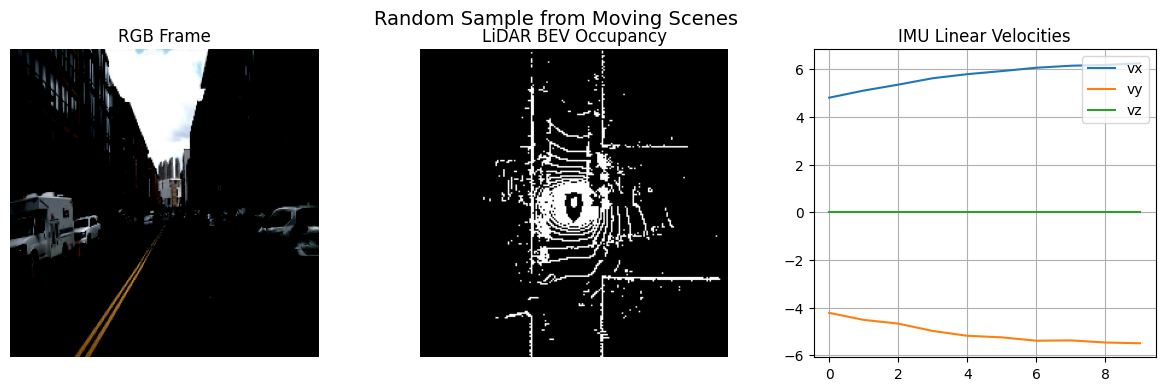

In [ ]:
import random, h5py, numpy as np, matplotlib.pyplot as plt, os

moving_dir = "/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/data/preprocessed_moving"
files = [os.path.join(moving_dir, f) for f in os.listdir(moving_dir) if f.endswith(".h5")]
sample_path = random.choice(files)
print("Sample:", sample_path)

with h5py.File(sample_path, "r") as f:
    rgb = np.array(f["rgb"])
    bev = np.array(f["bev"])
    imu = np.array(f["imu"])

print(f"RGB shape: {rgb.shape}, BEV shape: {bev.shape}, IMU shape: {imu.shape}")

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].imshow(np.transpose(rgb, (1, 2, 0))); axs[0].set_title("RGB Frame"); axs[0].axis("off")
axs[1].imshow(bev[0], cmap="gray"); axs[1].set_title("LiDAR BEV Occupancy"); axs[1].axis("off")
axs[2].plot(imu[:, 0], label="vx"); axs[2].plot(imu[:, 1], label="vy"); axs[2].plot(imu[:, 2], label="vz")
axs[2].legend(); axs[2].grid(True); axs[2].set_title("IMU Linear Velocities")
plt.suptitle("Random Sample from Moving Scenes", fontsize=14)
plt.show()


## Phase Summary

### Objectives Achieved

✓ Loaded synchronized NuScenes sensor data

✓ Preprocessed RGB imagery

✓ Converted LiDAR point clouds into Bird's-Eye-View occupancy maps

✓ Extracted ego-motion (IMU) feature windows

✓ Constructed synchronized multimodal HDF5 samples

✓ Generated a moving-scene subset for downstream training

### Output Artifacts

```
data/
├── preprocessed/
│   ├── sample_00000.h5
│   ├── sample_00001.h5
│   └── ...
│
└── preprocessed_moving/
    ├── sample_00000.h5
    ├── sample_00001.h5
    └── ...
```

These datasets form the foundation for all subsequent RGB, LiDAR,
and multimodal fusion models developed in Project 3.

Example Data samples

Selected samples
------------------------------------------------------------
sample_00057.h5
sample_00012.h5
sample_00181.h5

Saved dataset figure to:
/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/assets/dataset_examples.png


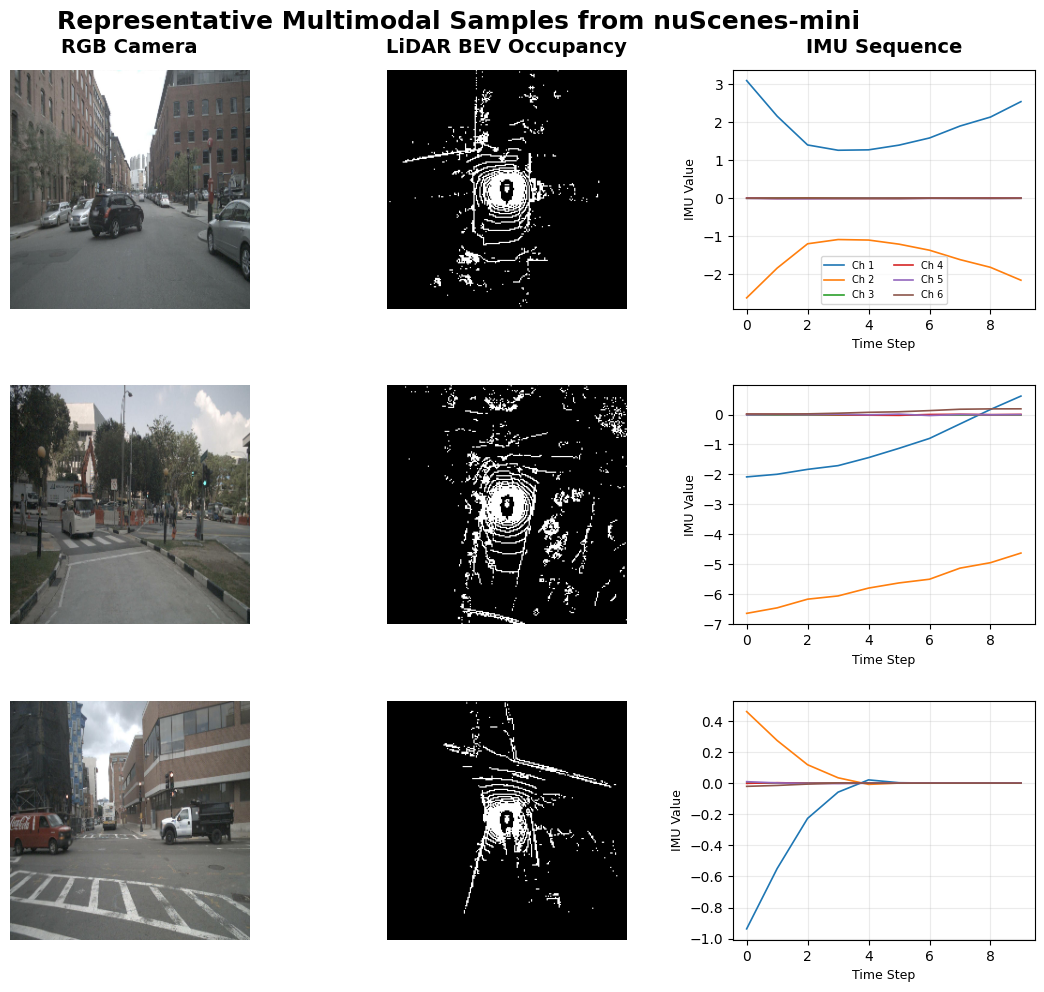

In [ ]:
# ============================================================
# Representative Dataset Examples
# ============================================================

from pathlib import Path
import random

import h5py
import matplotlib.pyplot as plt
import numpy as np


# ------------------------------------------------------------
# Paths and configuration
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/"
    "project3_multimodal_bev_perception"
)

DATASET_DIR = (
    PROJECT_ROOT
    / "data"
    / "preprocessed_moving"
)

OUTPUT_PATH = (
    PROJECT_ROOT
    / "assets"
    / "dataset_examples.png"
)

OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

NUM_SAMPLES = 3
RANDOM_SEED = 42


# ------------------------------------------------------------
# Locate processed samples
# ------------------------------------------------------------

sample_files = sorted(
    DATASET_DIR.glob("sample_*.h5")
)

if len(sample_files) < NUM_SAMPLES:
    raise ValueError(
        f"Requested {NUM_SAMPLES} samples, but only "
        f"{len(sample_files)} were found in:\n{DATASET_DIR}"
    )


# ------------------------------------------------------------
# Reproducible representative selection
# ------------------------------------------------------------

random.seed(RANDOM_SEED)

selected_files = random.sample(
    sample_files,
    NUM_SAMPLES,
)

print("Selected samples")
print("-" * 60)

for sample_file in selected_files:
    print(sample_file.name)


# ------------------------------------------------------------
# Load samples
# ------------------------------------------------------------

dataset_examples = []

for sample_file in selected_files:

    with h5py.File(sample_file, "r") as h5_file:

        rgb = h5_file["rgb"][()]
        bev = h5_file["bev"][()]
        imu = h5_file["imu"][()]

    # RGB is stored as CHW and normalized to [-1, 1].
    rgb_image = np.transpose(
        rgb,
        (1, 2, 0),
    )

    rgb_image = np.clip(
        (rgb_image + 1.0) / 2.0,
        0.0,
        1.0,
    )

    # Remove the single BEV channel dimension.
    bev_image = np.squeeze(bev)

    dataset_examples.append(
        {
            "filename": sample_file.name,
            "rgb": rgb_image,
            "bev": bev_image,
            "imu": imu,
        }
    )


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=NUM_SAMPLES,
    ncols=3,
    figsize=(12, 10),
)

column_titles = [
    "RGB Camera",
    "LiDAR BEV Occupancy",
    "IMU Sequence",
]

for column_index, title in enumerate(column_titles):

    axes[0, column_index].set_title(
        title,
        fontsize=14,
        fontweight="bold",
        pad=12,
    )


for row_index, sample in enumerate(dataset_examples):

    # --------------------------------------------------------
    # RGB camera
    # --------------------------------------------------------

    axes[row_index, 0].imshow(
        sample["rgb"],
    )

    axes[row_index, 0].axis("off")


    # --------------------------------------------------------
    # LiDAR-derived BEV occupancy
    # --------------------------------------------------------

    axes[row_index, 1].imshow(
        sample["bev"],
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axes[row_index, 1].axis("off")


    # --------------------------------------------------------
    # IMU temporal sequence
    # --------------------------------------------------------

    imu = sample["imu"]

    time_steps = np.arange(
        imu.shape[0]
    )

    for channel_index in range(imu.shape[1]):

        axes[row_index, 2].plot(
            time_steps,
            imu[:, channel_index],
            linewidth=1.2,
            label=f"Ch {channel_index + 1}",
        )

    axes[row_index, 2].set_xlabel(
        "Time Step",
        fontsize=9,
    )

    axes[row_index, 2].set_ylabel(
        "IMU Value",
        fontsize=9,
    )

    axes[row_index, 2].grid(
        alpha=0.25,
    )

    if row_index == 0:

        axes[row_index, 2].legend(
            fontsize=7,
            ncol=2,
            loc="best",
        )


    # --------------------------------------------------------
    # Row label
    # --------------------------------------------------------

    axes[row_index, 0].set_ylabel(
        f"Sample {row_index + 1}",
        fontsize=12,
        fontweight="bold",
        rotation=0,
        labelpad=48,
        va="center",
    )


# ------------------------------------------------------------
# Figure title
# ------------------------------------------------------------

fig.suptitle(
    "Representative Multimodal Samples from nuScenes-mini",
    fontsize=18,
    fontweight="bold",
    y=0.99,
)


# ------------------------------------------------------------
# Layout and export
# ------------------------------------------------------------

plt.subplots_adjust(
    left=0.10,
    right=0.98,
    top=0.93,
    bottom=0.06,
    wspace=0.25,
    hspace=0.32,
)

fig.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight",
)

print(f"\nSaved dataset figure to:\n{OUTPUT_PATH}")

plt.show()

Selected Samples
------------------------------------------------------------
sample_00057.h5
sample_00012.h5
sample_00181.h5

Saved dataset figure to:
/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/assets/dataset_examples.png


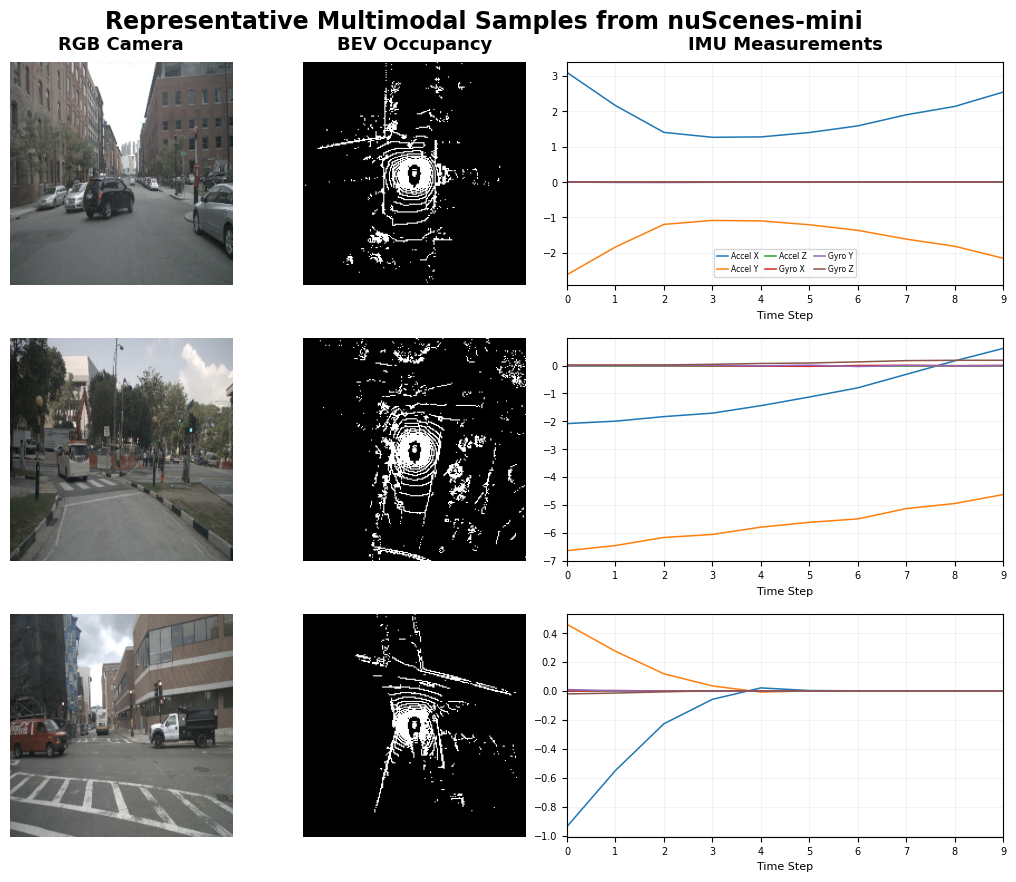

In [ ]:
# ============================================================
# Representative Dataset Examples
# ============================================================

from pathlib import Path
import random

import h5py
import matplotlib.pyplot as plt
import numpy as np


# ------------------------------------------------------------
# Paths and configuration
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/"
    "project3_multimodal_bev_perception"
)

DATASET_DIR = (
    PROJECT_ROOT
    / "data"
    / "preprocessed_moving"
)

OUTPUT_PATH = (
    PROJECT_ROOT
    / "assets"
    / "dataset_examples.png"
)

OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

NUM_SAMPLES = 3
RANDOM_SEED = 42


# ------------------------------------------------------------
# IMU channel labels
# ------------------------------------------------------------

IMU_LABELS = [
    "Accel X",
    "Accel Y",
    "Accel Z",
    "Gyro X",
    "Gyro Y",
    "Gyro Z",
]


# ------------------------------------------------------------
# Locate processed samples
# ------------------------------------------------------------

sample_files = sorted(
    DATASET_DIR.glob("sample_*.h5")
)

if len(sample_files) < NUM_SAMPLES:
    raise ValueError(
        f"Requested {NUM_SAMPLES} samples, but only "
        f"{len(sample_files)} were found in:\n{DATASET_DIR}"
    )


# ------------------------------------------------------------
# Reproducible representative selection
# ------------------------------------------------------------

random.seed(RANDOM_SEED)

selected_files = random.sample(
    sample_files,
    NUM_SAMPLES,
)

print("Selected Samples")
print("-" * 60)

for sample_file in selected_files:
    print(sample_file.name)


# ------------------------------------------------------------
# Load samples
# ------------------------------------------------------------

dataset_examples = []

for sample_file in selected_files:

    with h5py.File(sample_file, "r") as h5_file:
        rgb = h5_file["rgb"][()]
        bev = h5_file["bev"][()]
        imu = h5_file["imu"][()]

    # RGB: CHW in [-1, 1] -> HWC in [0, 1].
    rgb_image = np.transpose(
        rgb,
        (1, 2, 0),
    )

    rgb_image = np.clip(
        (rgb_image + 1.0) / 2.0,
        0.0,
        1.0,
    )

    bev_image = np.squeeze(bev)

    dataset_examples.append(
        {
            "filename": sample_file.name,
            "rgb": rgb_image,
            "bev": bev_image,
            "imu": imu,
        }
    )


# ------------------------------------------------------------
# Create compact figure
#
# The narrower figure is important. A very wide figure creates
# wide subplot cells, while square images retain their aspect
# ratio and leave blank space inside those cells.
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=NUM_SAMPLES,
    ncols=3,
    figsize=(10.6, 8.8),
    gridspec_kw={
        "width_ratios": [
            1.0,   # RGB
            1.0,   # BEV
            1.55,  # IMU
        ],
        "wspace": 0.035,
        "hspace": 0.24,
    },
)


# ------------------------------------------------------------
# Column titles
# ------------------------------------------------------------

column_titles = [
    "RGB Camera",
    "BEV Occupancy",
    "IMU Measurements",
]

for column_index, title in enumerate(column_titles):

    axes[0, column_index].set_title(
        title,
        fontsize=13,
        fontweight="bold",
        pad=9,
    )


# ------------------------------------------------------------
# Populate figure
# ------------------------------------------------------------

for row_index, sample in enumerate(dataset_examples):

    # --------------------------------------------------------
    # RGB camera
    # --------------------------------------------------------

    axes[row_index, 0].imshow(
        sample["rgb"],
    )

    # Force the axes themselves to be square.
    axes[row_index, 0].set_box_aspect(1)
    axes[row_index, 0].axis("off")


    # --------------------------------------------------------
    # LiDAR-derived BEV occupancy
    # --------------------------------------------------------

    axes[row_index, 1].imshow(
        sample["bev"],
        cmap="gray",
        vmin=0,
        vmax=1,
    )

    axes[row_index, 1].set_box_aspect(1)
    axes[row_index, 1].axis("off")


    # --------------------------------------------------------
    # IMU temporal sequence
    # --------------------------------------------------------

    imu = sample["imu"]

    if imu.ndim != 2:
        raise ValueError(
            f"Expected IMU shape [T, C], but received "
            f"{imu.shape} for {sample['filename']}."
        )

    time_steps = np.arange(
        imu.shape[0]
    )

    num_channels = min(
        imu.shape[1],
        len(IMU_LABELS),
    )

    for channel_index in range(num_channels):

        axes[row_index, 2].plot(
            time_steps,
            imu[:, channel_index],
            linewidth=1.1,
            label=IMU_LABELS[channel_index],
        )

    axes[row_index, 2].set_xlim(
        time_steps.min(),
        time_steps.max(),
    )

    axes[row_index, 2].set_xlabel(
        "Time Step",
        fontsize=8,
    )

    axes[row_index, 2].set_ylabel("")

    axes[row_index, 2].grid(
        alpha=0.15,
    )

    axes[row_index, 2].tick_params(
        axis="both",
        labelsize=7,
    )

    if row_index == 0:

        axes[row_index, 2].legend(
            fontsize=5.5,
            ncol=3,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.02),
            frameon=True,
            columnspacing=0.9,
            handlelength=1.4,
            handletextpad=0.4,
        )


# ------------------------------------------------------------
# Figure title
# ------------------------------------------------------------

fig.suptitle(
    "Representative Multimodal Samples from nuScenes-mini",
    fontsize=17,
    fontweight="bold",
    y=0.985,
)


# ------------------------------------------------------------
# Final layout adjustment
# ------------------------------------------------------------

fig.subplots_adjust(
    left=0.025,
    right=0.99,
    top=0.925,
    bottom=0.045,
)


# ------------------------------------------------------------
# Export
# ------------------------------------------------------------

fig.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.04,
)

print(f"\nSaved dataset figure to:\n{OUTPUT_PATH}")

plt.show()